# Python REPL Example


In [ ]:
import operator
import os
from typing import Annotated, Any, Dict, Sequence
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send, Command
from langgraph.checkpoint.memory import MemorySaver

In [2]:
# Initialize LLM Engine (Ensure GROQ_API_KEY is available in your environment)
# llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.2)

def get_groq_llm() -> ChatOpenAI:
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7,
        max_tokens=2000
    )

llm = get_groq_llm()

In [3]:
# Instantiate the native Python REPL interface
repl_engine = PythonREPL()

## State definition & REPL Tool

In [4]:
class MathAgentState(TypedDict):
    # Tracks the full conversation loop history
    messages: Annotated[Sequence[BaseMessage], operator.add]

    # Tracks code generated across iterations
    current_code: str

    # Safety iteration ceiling counter to prevent infinite token burn
    execution_loops: Annotated[int, operator.add]

    # Final confirmed answer string
    final_solution: str


@tool
def python_compiler_tool(code_string: str) -> str:
    """
    Executes a string of Python code in an isolated REPL console environment.
    Always make sure to 'print()' your variables to see their value output.
    """
    try:
        execution_result = repl_engine.run(code_string)
        if not execution_result.strip():
            return "Executed successfully, but forgot to call print() to display output."
        return execution_result.strip()
    except Exception as error:
        return f"RUNTIME EXCEPTION:\n{str(error)}"

### 1. Node - Output Structure

In [5]:
class CodeGenerationSchema(BaseModel):
    reasoning: str = Field(description="Step-by-step breakdown of how to translate the word problem into math variables.")
    python_script: str = Field(description="Pure Python code block. Must print() the final numerical value to stdout.")


structured_compiler = llm.with_structured_output(CodeGenerationSchema)

### 2. Node - Code Generator

In [6]:
def code_generator_node(state: MathAgentState) -> Dict[str, Any]:
    print(f"\n[NODE] Code Generator - Turn Count: {state.get('execution_loops', 0)}")

    system_prompt = (
        "You are an expert computational mathematician. Your job is to translate complex math word "
        "problems into perfectly executable Python scripts. Always use print() statements to log outputs."
    )

    # Pack up existing message history + prompt parameters
    api_messages = [
        SystemMessage(
            content=system_prompt
            )
        ] + list(state["messages"])

    # If we are looping back from an error, prompt the model to adjust its code
    if state.get("current_code"):
        api_messages.append(
            HumanMessage(content=f"Your previous code draft failed or was rejected. Review your bugs and fix it.")
        )

    structured_response = structured_compiler.invoke(api_messages)

    return {
        "current_code": structured_response.python_script,
        "execution_loops": 1,  # Reducer adds 1 to the loop count
        "messages": [AIMessage(content=f"Generated implementation:\n{structured_response.python_script}")]
    }

### 3. Node - Execution Py REPL 

In [7]:
def execution_repl_node(state: MathAgentState) -> Dict[str, Any]:
    print("[NODE] Python REPL Execution Engine")
    target_script = state["current_code"]

    # Execute code string directly in the REPL tool environment
    terminal_output = python_compiler_tool.invoke({"code_string": target_script})

    print(f"[REPL OUTPUT]:\n{terminal_output}")

    return {
        "messages": [HumanMessage(content=f"REPL Engine Console Output:\n{terminal_output}")]
    }

### 4. Node - Conditional Router

In [8]:
def self_correcting_router(state: MathAgentState) -> str:
    latest_message_text = state["messages"][-1].content

    # Condition A: Hard token protection cap gate
    if state["execution_loops"] >= 4:
        print("[ROUTER] ⚠️ Hard Loop Ceiling Reached. Terminating pipeline execution safely.")
        return "route_to_final_answer"

    # Condition B: Python code crashed or raised an exception inside the REPL environment
    if "RUNTIME EXCEPTION" in latest_message_text or "forgot to call print()" in latest_message_text:
        print("[ROUTER] ❌ Compilation Error or Empty Buffer Found. Routing back to Generator Node for Self-Correction.")
        return "loop_for_correction"

    # Condition C: Successful validation run with stdout outputs collected
    print("[ROUTER] ✅ Mathematical Execution Complete. Passing to synthesis node.")
    return "route_to_final_answer"

### Node - Final Answer

In [9]:
def final_answer_node(state: MathAgentState) -> Dict[str, Any]:
    print("[NODE] Final Answer Synthesis Node")

    synthesis_prompt = (
        "Review the original math problem and look at the terminal output generated by the Python code execution. "
        "Format a clear final sentence presenting the mathematical conclusion accurately."
    )

    final_output = llm.invoke([SystemMessage(content=synthesis_prompt)] + list(state["messages"]))
    return {"final_solution": final_output.content}

## Compilation

In [10]:
builder = StateGraph(MathAgentState)

# Define core workflow processing stations
builder.add_node("code_generator_node", code_generator_node)
builder.add_node("execution_repl_node", execution_repl_node)
builder.add_node("final_answer_node", final_answer_node)

# Map edge topologies
builder.add_edge(START, "code_generator_node")
builder.add_edge("code_generator_node", "execution_repl_node")

# Attach the intelligent self-correcting conditional edge router
builder.add_conditional_edges(
    "execution_repl_node",
    self_correcting_router,
    {
        "loop_for_correction": "code_generator_node",
        "route_to_final_answer": "final_answer_node"
    }
)
builder.add_edge("final_answer_node", END)

# Compile into a runnable stateful binary graph with short-term checkpoints
checkpointer = MemorySaver()
compiled_math_graph = builder.compile(checkpointer=checkpointer)

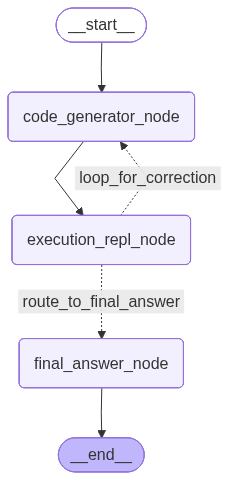

In [11]:
compiled_math_graph

In [12]:
if __name__ == "__main__":
    complex_math_query = (
        "A technology company has 14,250 servers. 35% run Ubuntu, 42% run CentOS, "
        "and the remainder run RedHat. If an automated script patches 12% of the Ubuntu "
        "servers, 18% of the CentOS servers, and 25% of the RedHat servers every hour, "
        "exactly how many total servers remain unpatched across all distributions after 1 hour? "
        "Show your work via variable scripts."
    )

    initial_input = {
        "messages": [HumanMessage(content=complex_math_query)],
        "current_code": "",
        "execution_loops": 0,
        "final_solution": ""
    }

    config = {"configurable": {"thread_id": "math_verification_session"}}

    print("🚀 RUNNING AUTOMATED COMPILER WORKFLOW...")
    for event in compiled_math_graph.stream(initial_input, config=config, stream_mode="values"):
        if "final_solution" in event and event["final_solution"]:
            print("\n🏁 [FINAL ANSWER CONCLUSION]:")
            print(event["final_solution"])

🚀 RUNNING AUTOMATED COMPILER WORKFLOW...

[NODE] Code Generator - Turn Count: 0


Python REPL can execute arbitrary code. Use with caution.


[NODE] Python REPL Execution Engine
[REPL OUTPUT]:
11755
[ROUTER] ✅ Mathematical Execution Complete. Passing to synthesis node.
[NODE] Final Answer Synthesis Node

🏁 [FINAL ANSWER CONCLUSION]:
**Answer: After one hour, 11 755 servers remain unpatched across all distributions.**
